In [4]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from plotly import express as px
import plotly.figure_factory as ff
from sklearn.linear_model import LinearRegression

import warnings, os
import mysql.connector as mysql
warnings.filterwarnings('ignore')
username = os.environ['MYSQL_user']
password = os.environ['MYSQL_password']
DB = mysql.connect(host = "localhost", user = username, passwd = password, database = "AIRBNB")
cursor = DB.cursor(buffered=True)

## Utils

In [5]:
def read_table_from_db(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', con=DB)
    return df

In [6]:
class Plots:
    def __init__(self):
        self.quantiles_dict = {"Min": 0, "Q1": 0.25, "Med": 0.5, "Q3": 0.75, "Max": 1}

    def histogram_and_box_plot(self, data, name="", annotations=True, bin_size=1):
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "histogram"}, {"type": "box"}]])
        fig.add_trace(go.Box(y=data, name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data, marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data, self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data, self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data, value), text=key + ": " + str(np.round(np.quantile(data, value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def bar_chart(self, data, column, title=""):
        colors = px.colors.qualitative.Dark24
        fig = go.Figure()
        for class_name in data[column].unique():
            count = len(data[data[column] == class_name])
            fig.add_trace(go.Bar(name=class_name, x=[class_name], y=[count], text=[f"{count}"], marker=dict(color=colors[data[column].unique().tolist().index(class_name)])))
        fig.update_layout(template="simple_white", width=1200, height=800, title=f"<b>{title}<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")

    def correlation_plot(self, data, method="spearman"):
        corr = np.round(data[data.columns.tolist()].corr(method=method), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=2000, height=2000, xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=12,color="Black"))
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
plots = Plots()

# Load datasets

In [7]:
listings = read_table_from_db('inside_airbnb')
listings

,listing_id,listing_url,last_scraped,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry
0,2595,https://www.airbnb.com/rooms/2595,2024-09-05,2845,2008-09-09,within a day,67%,24%,f,7.0,...,4.80,4.81,4.40,f,3,3,0,0,0.27,POINT (-73.98559 40.75356)
1,5121,https://www.airbnb.com/rooms/5121,2024-04-07,7356,2009-02-03,within a day,100%,0%,f,2.0,...,4.91,4.47,4.52,f,2,0,2,0,0.28,POINT (-73.95512 40.68535)
2,5136,https://www.airbnb.com/rooms/5136,2024-09-04,7378,2009-02-03,within an hour,100%,100%,f,1.0,...,5.00,4.75,4.75,t,1,1,0,0,0.03,POINT (-73.99454 40.66265)
3,6848,https://www.airbnb.com/rooms/6848,2024-09-05,15991,2009-05-06,within an hour,100%,100%,t,1.0,...,4.80,4.69,4.58,f,1,1,0,0,1.04,POINT (-73.95342 40.70935)
4,6872,https://www.airbnb.com/rooms/6872,2024-09-04,16104,2009-05-07,within a day,50%,0%,f,2.0,...,5.00,5.00,5.00,f,2,0,2,0,0.04,POINT (-73.94255 40.80107)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35573,1277527400878120655,https://www.airbnb.com/rooms/1277527400878120655,2024-11-05,382970529,2021-01-04,within an hour,100%,98%,t,14.0,...,NaN,NaN,NaN,t,14,3,11,0,NaN,POINT (-73.7617826 42.654727)
35574,1277717926531215616,https://www.airbnb.com/rooms/1277717926531215616,2024-11-05,65760,2009-12-26,within a few hours,100%,None,f,1.0,...,NaN,NaN,NaN,f,1,1,0,0,NaN,POINT (-73.7645287 42.6497616)
35575,1279011643102137684,https://www.airbnb.com/rooms/1279011643102137684,2024-11-05,539608284,2023-09-29,within an hour,100%,65%,f,13.0,...,NaN,NaN,NaN,t,3,0,3,0,NaN,POINT (-73.76204655881854 42.66139590406264)
35576,1279781671588026640,https://www.airbnb.com/rooms/1279781671588026640,2024-11-05,528617680,2023-07-29,within an hour,100%,100%,f,1.0,...,4.00,3.00,4.00,f,1,0,1,0,1.00,POINT (-73.75793399720892 42.6453112779392)


In [8]:
table_name = "images"
images_data = df = read_table_from_db(table_name)
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1
...,...,...,...,...,...,...,...
382475,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1
382476,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1
382477,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1
382478,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384123,1


In [9]:
table_name = "images_color_attributes"
images_color_attributes_data = read_table_from_db(table_name)
images_color_attributes_data

,id,warmth_hue,saturation,brightness,contrast_brightness,clarity
0,1,0.870311,0.156989,0.212105,0.266914,0.096382
1,2,0.610155,0.273740,0.545901,0.243398,0.382092
2,3,0.173552,0.253439,0.503338,0.267396,0.241613
3,4,0.983737,0.265499,0.566499,0.187269,0.356617
4,5,0.517305,0.132521,0.540238,0.259135,0.316075
...,...,...,...,...,...,...
382475,384120,0.999763,0.207686,0.786549,0.099478,0.863692
382476,384121,0.762999,0.209219,0.716846,0.129519,0.570378
382477,384122,0.897917,0.400995,0.651478,0.110679,0.381406
382478,384123,0.838707,0.300679,0.559413,0.199620,0.328076


In [10]:
# table_name = "images_composition_attributes"
# images_composition_attributes_data = read_table_from_db(table_name)
# images_composition_attributes_data

In [11]:
images_data = images_data.merge(images_color_attributes_data, on="id", how="inner")
# images_data = images_data.merge(images_composition_attributes_data, on="id", how="inner")
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted,warmth_hue,saturation,brightness,contrast_brightness,clarity
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0,0.870311,0.156989,0.212105,0.266914,0.096382
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0,0.610155,0.273740,0.545901,0.243398,0.382092
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1,0.173552,0.253439,0.503338,0.267396,0.241613
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1,0.983737,0.265499,0.566499,0.187269,0.356617
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1,0.517305,0.132521,0.540238,0.259135,0.316075
...,...,...,...,...,...,...,...,...,...,...,...,...
382475,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1,0.999763,0.207686,0.786549,0.099478,0.863692
382476,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1,0.762999,0.209219,0.716846,0.129519,0.570378
382477,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1,0.897917,0.400995,0.651478,0.110679,0.381406
382478,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384123,1,0.838707,0.300679,0.559413,0.199620,0.328076


# Preprocessing

## Remove listings without images

Remove listings for which URL was not found (unable to scrape images for those listings).

In [12]:
images_data = images_data[images_data['image_url'] != 'URL not found']
images_data = images_data.reset_index(drop=True)
images_data

,listing_id,listing_url,image_url,image,room_type,id,is_predicted,warmth_hue,saturation,brightness,contrast_brightness,clarity
0,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/5401233b-a...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,1,0,0.870311,0.156989,0.212105,0.266914,0.096382
1,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,dining_room,2,0,0.610155,0.273740,0.545901,0.243398,0.382092
2,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,3,1,0.173552,0.253439,0.503338,0.267396,0.241613
3,10887847,https://www.airbnb.com/rooms/10887847,https://a0.muscache.com/im/pictures/hosting/Ho...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,4,1,0.983737,0.265499,0.566499,0.187269,0.356617
4,668902255426418000,https://www.airbnb.com/rooms/668902255426418000,https://a0.muscache.com/im/pictures/miso/Hosti...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bedroom,5,1,0.517305,0.132521,0.540238,0.259135,0.316075
...,...,...,...,...,...,...,...,...,...,...,...,...
369390,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384119,1,0.993663,0.175981,0.681702,0.120501,0.611887
369391,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,bathroom,384120,1,0.999763,0.207686,0.786549,0.099478,0.863692
369392,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384121,1,0.762999,0.209219,0.716846,0.129519,0.570378
369393,923815513633030246,https://www.airbnb.com/rooms/923815513633030246,https://a0.muscache.com/im/pictures/prohost-ap...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,living_room,384122,1,0.897917,0.400995,0.651478,0.110679,0.381406


We will also update the `listings` DataFrame to exclude these listings.

In [13]:
listings = listings[listings['listing_id'].isin(images_data['listing_id'])]
print(f"Number of listings with images: {listings.shape[0]}")

Number of listings with images: 19737


## Duplicated images

We will show how many images are duplicated in the dataset.

Because some of the listings may contain same image (for instance the Statue of Liberty), we will have to not only check if images are duplicated, but also if they are duplicated for the same listing.

In [14]:
print(f"Number of duplicates in the dataset: {images_data.duplicated(subset=['listing_id', 'image']).sum()}")
print(f"Percentage of duplicates in the dataset: {images_data.duplicated(subset=['listing_id', 'image']).sum()/images_data.shape[0]*100:.2f}%")

Number of duplicates in the dataset: 4152
Percentage of duplicates in the dataset: 1.12%


As we can see there are slightly more than 1 percent of duplicated images in the dataset.

We will remove duplicates from the dataset.

In [15]:
images_data.drop_duplicates(subset=['listing_id', 'image'], inplace=True)

# Visualization

## `number_of_images`

We will show how many images are there for each listing.

Firstly we will have to create a new column in the `listings` DataFrame that will contain the number of images for each listing.

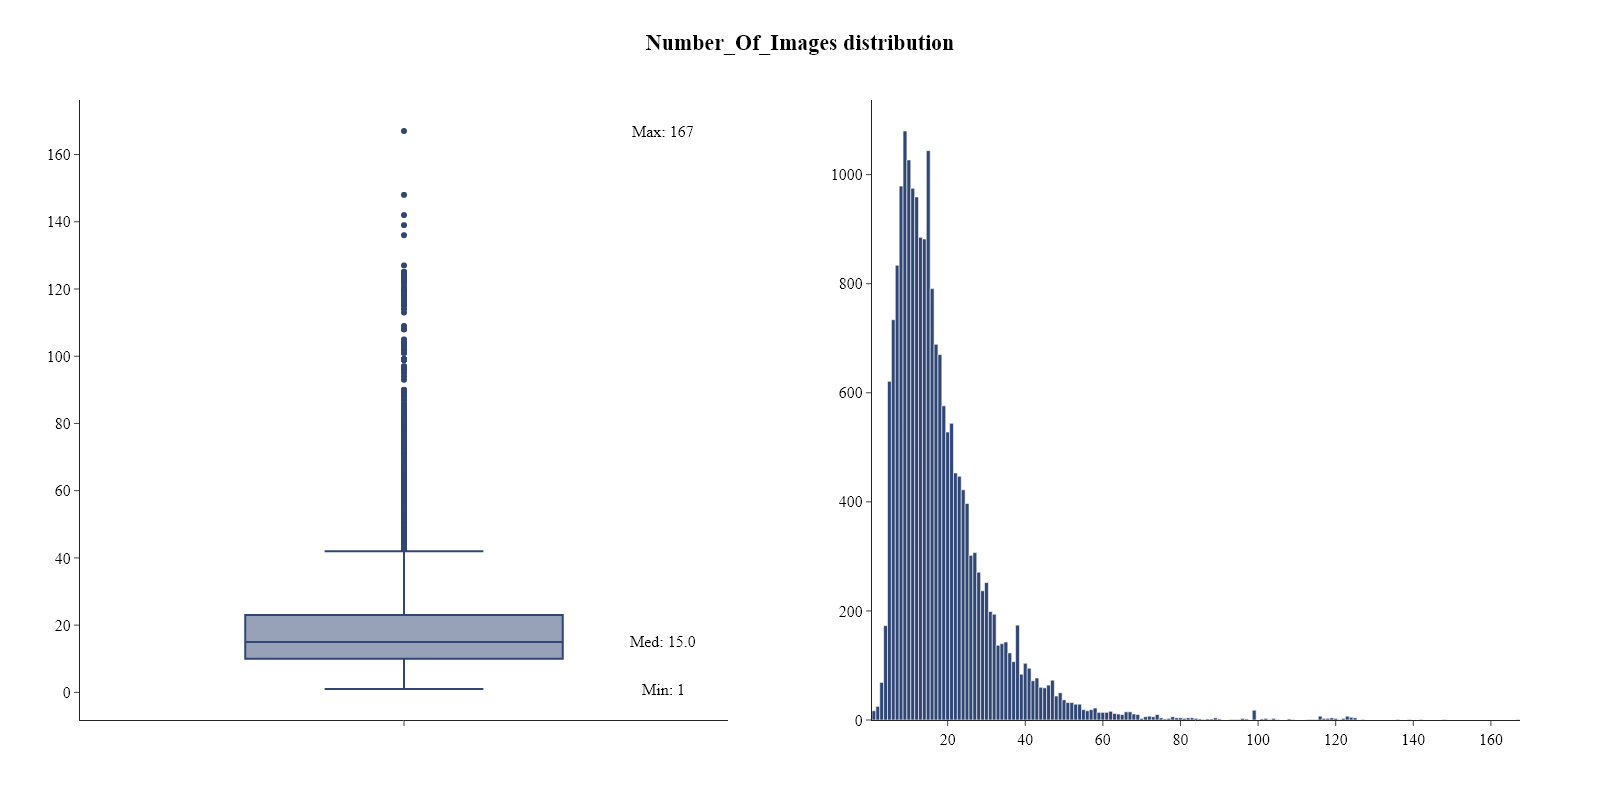

In [16]:
listings["number_of_images"] = listings["listing_id"].map(images_data["listing_id"].value_counts())
plots.histogram_and_box_plot(listings['number_of_images'], name="number_of_images", annotations=["Min", "Med", "Max"], bin_size=1)

In [17]:
full_df = pd.DataFrame()
for feature in ["number_of_images"]:
    describe = listings[feature].describe()[["min", "50%", "mean", "max", "std"]].round(2).to_frame().T
    describe = describe.applymap(lambda x: int(x) if str(x).endswith(".0") else x)
    full_df = pd.concat([full_df, describe])
full_df

,min,50%,mean,max,std
number_of_images,1,15,18.51,167,13.29


**Notes:**
- The number of images variable is right-skewed with median equals to 15.
- Listing with the most images has 167 images.
- Based on the Linear relationship between the number of images and the `log_price`, we can see that with the increase of the number of images, the price of the listing increases.

## `room_type`

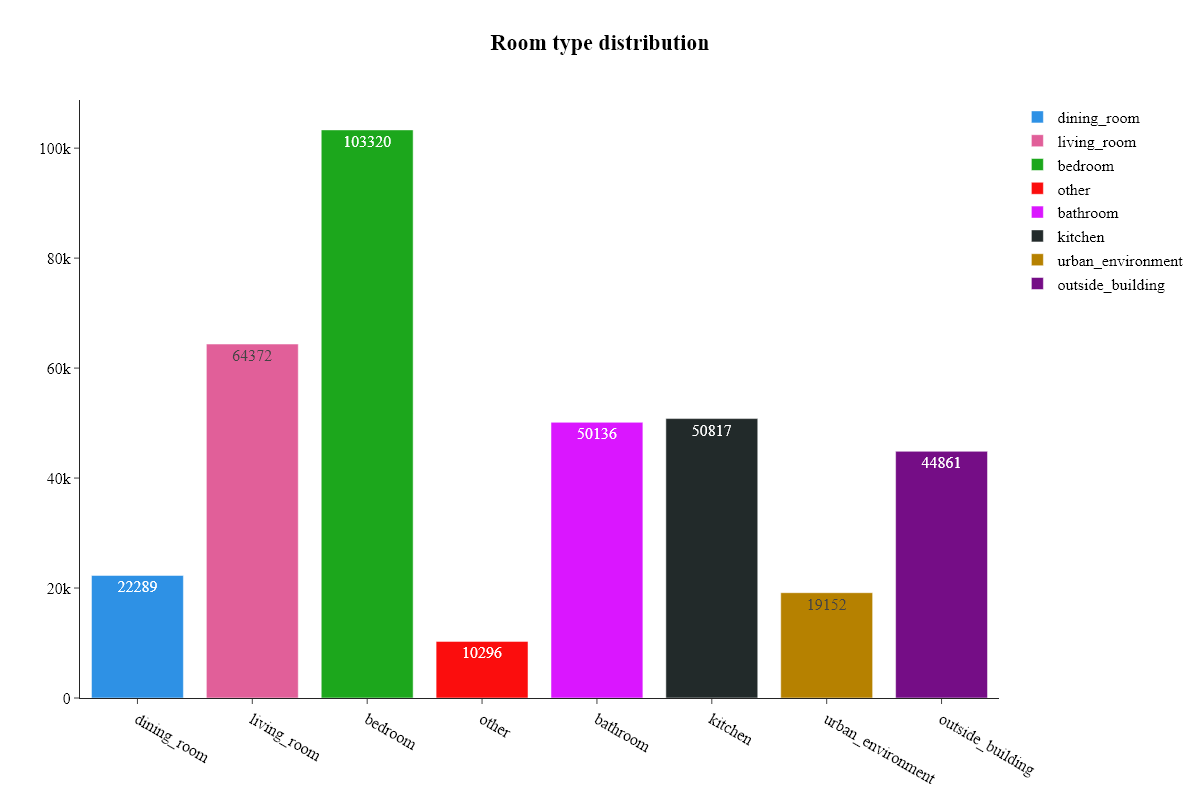

In [18]:
plots.bar_chart(images_data, "room_type", title="Room type distribution")

In [19]:
#Show value_counts for each room type
# images_data['room_type'].value_counts().to_frame().T
#Show also normalized value_counts for each room type
images_data['room_type'].value_counts(normalize=True).to_frame().T

room_type,bedroom,living_room,kitchen,bathroom,outside_building,dining_room,urban_environment,other
proportion,0.28288,0.176244,0.139132,0.137268,0.122825,0.061025,0.052436,0.028189


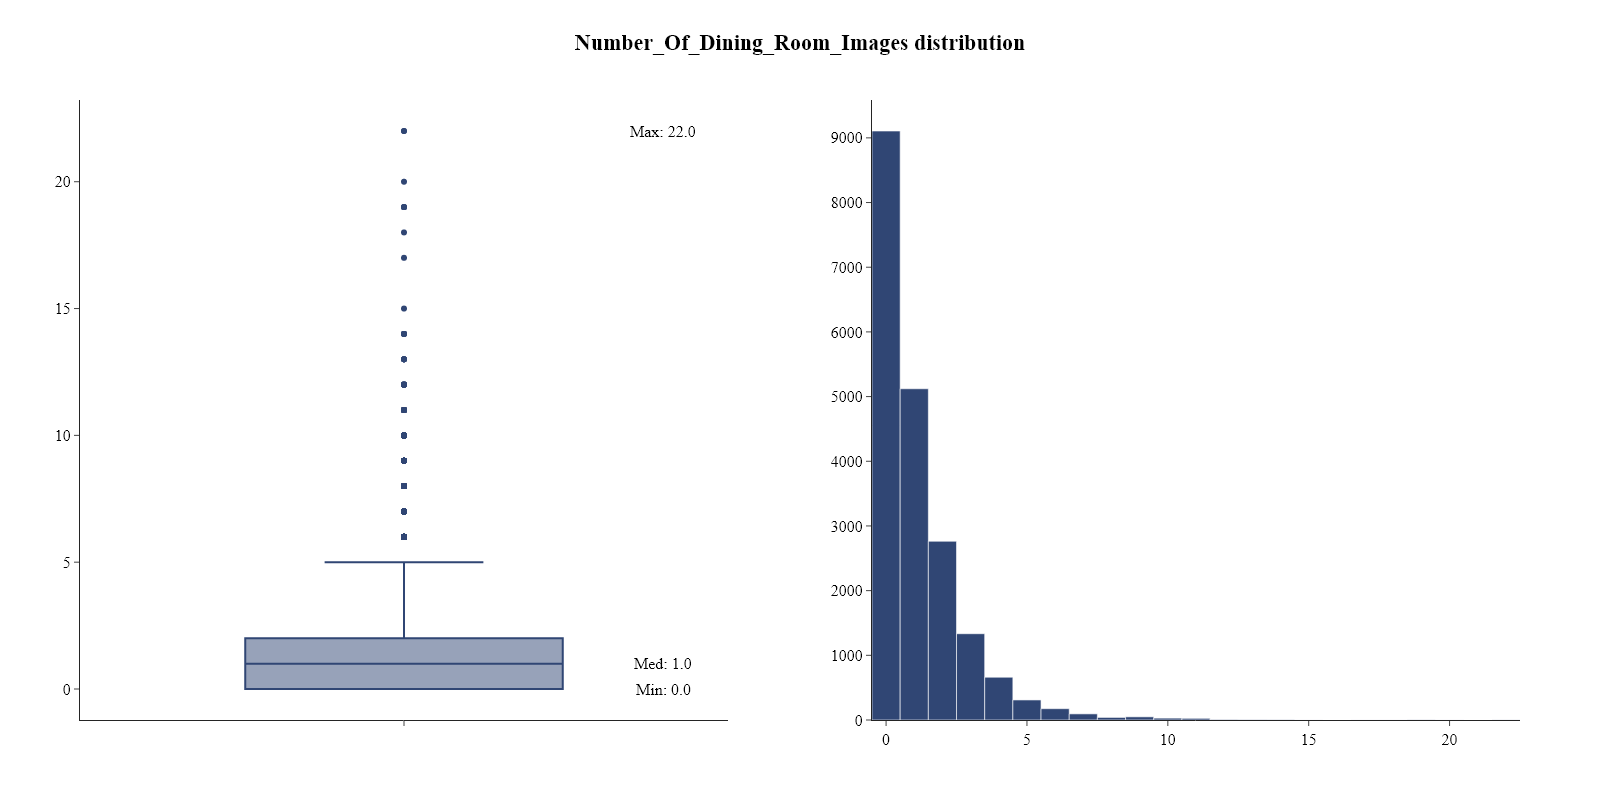

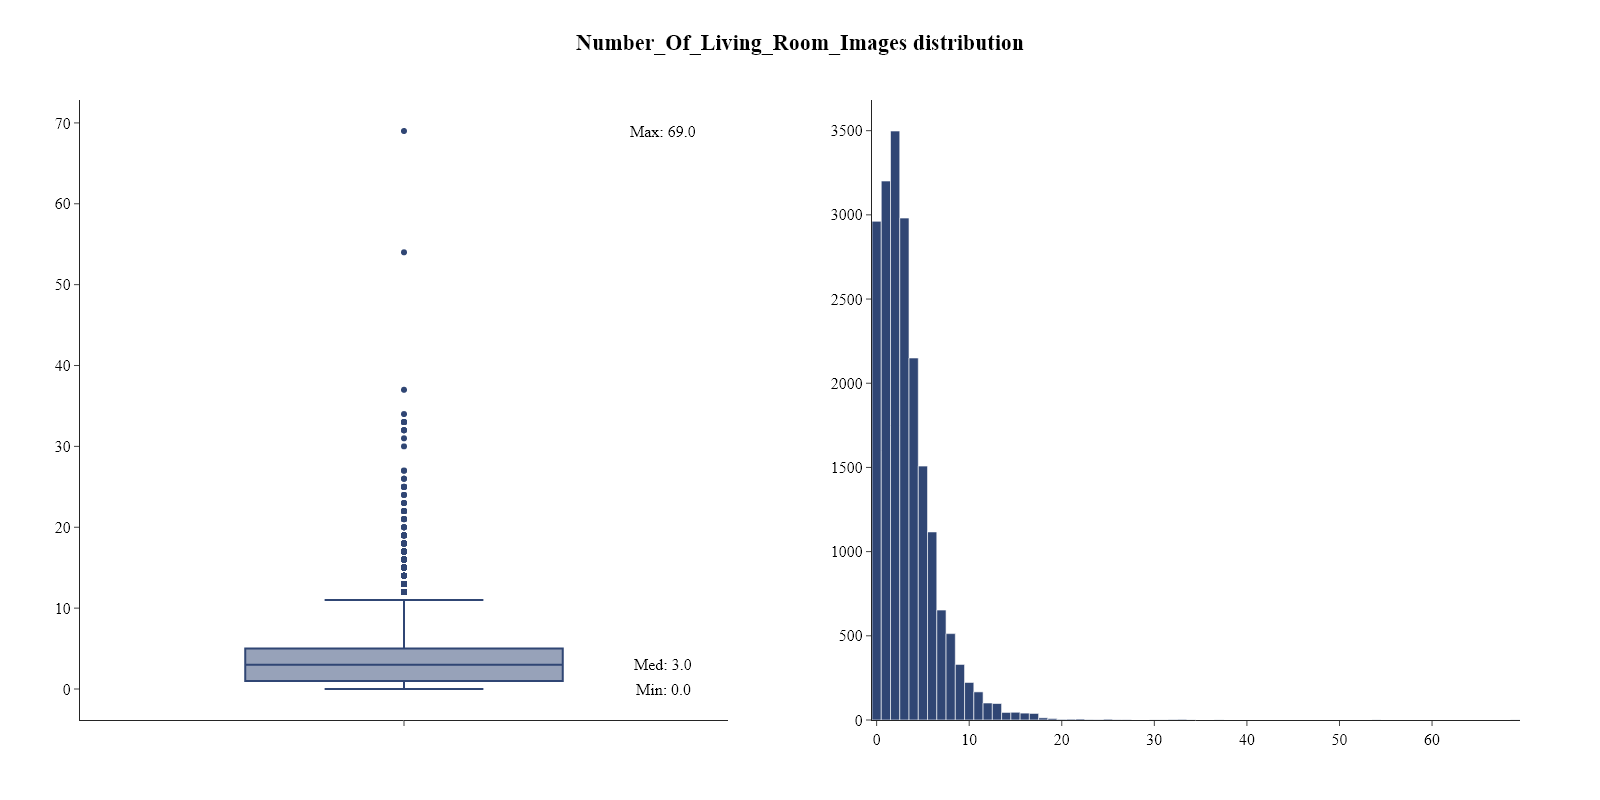

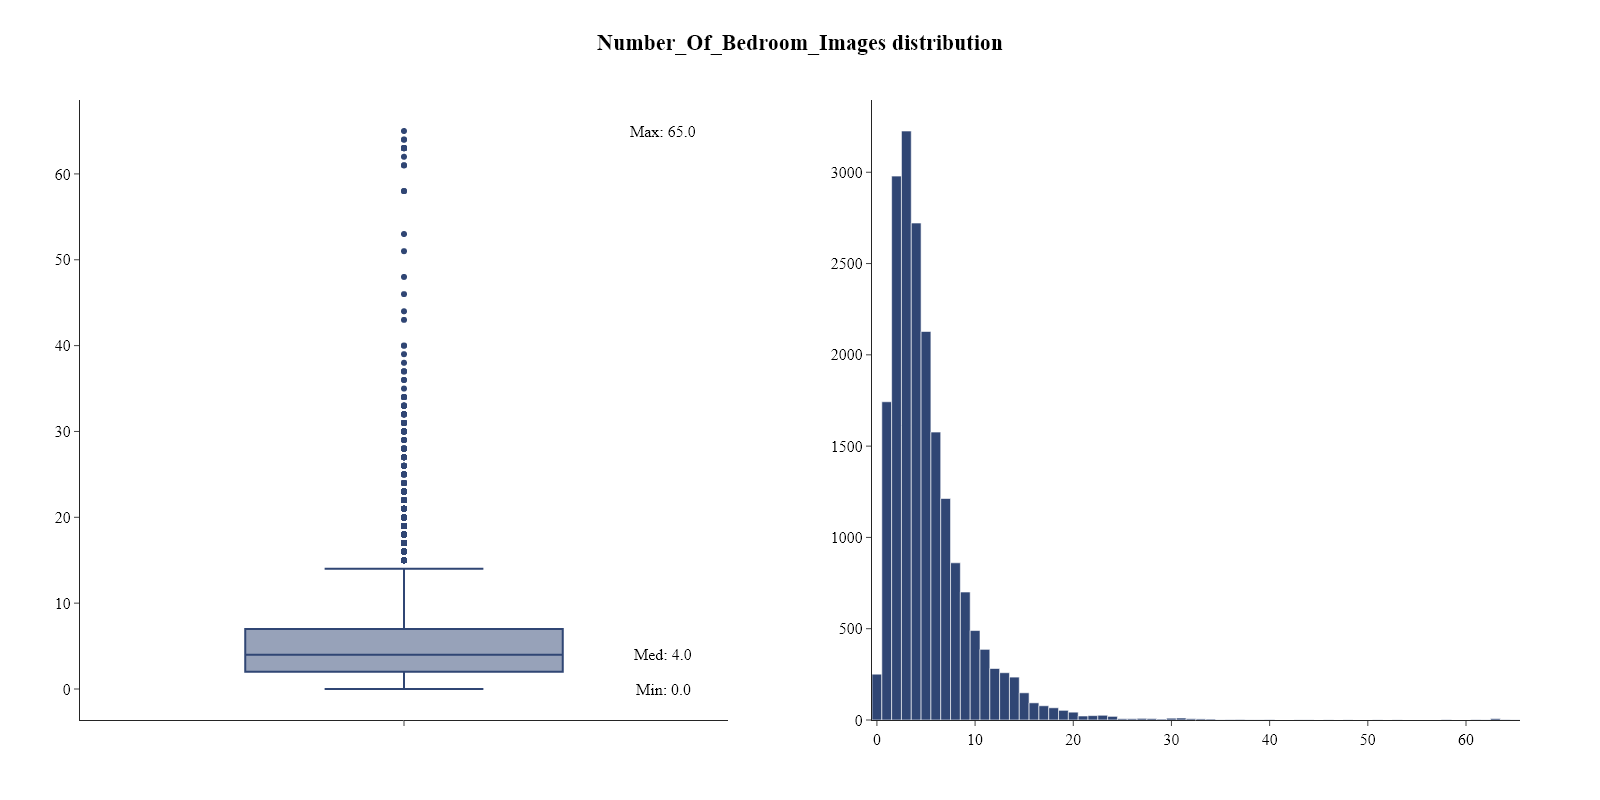

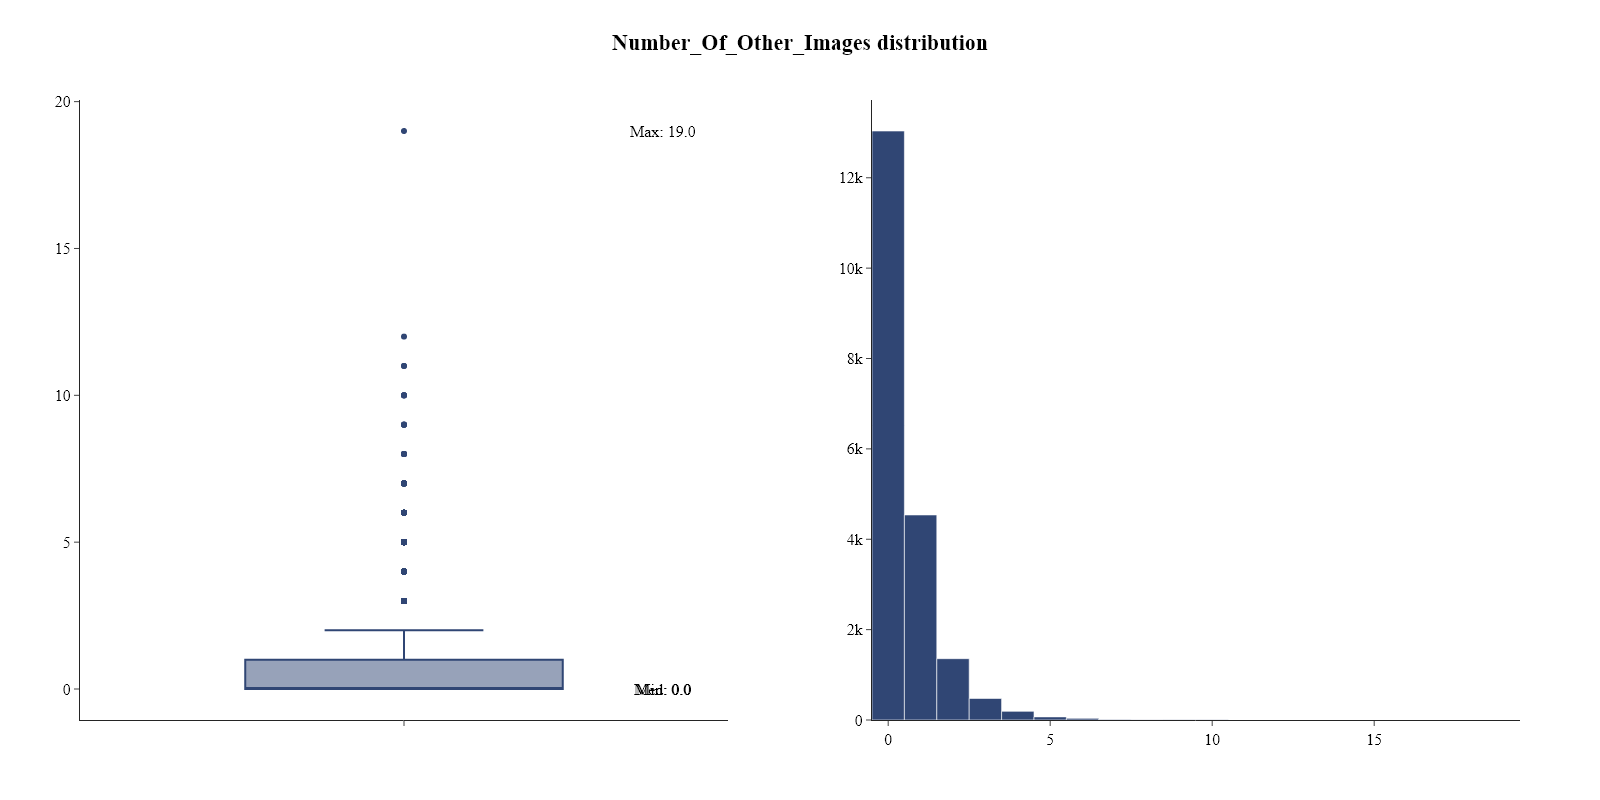

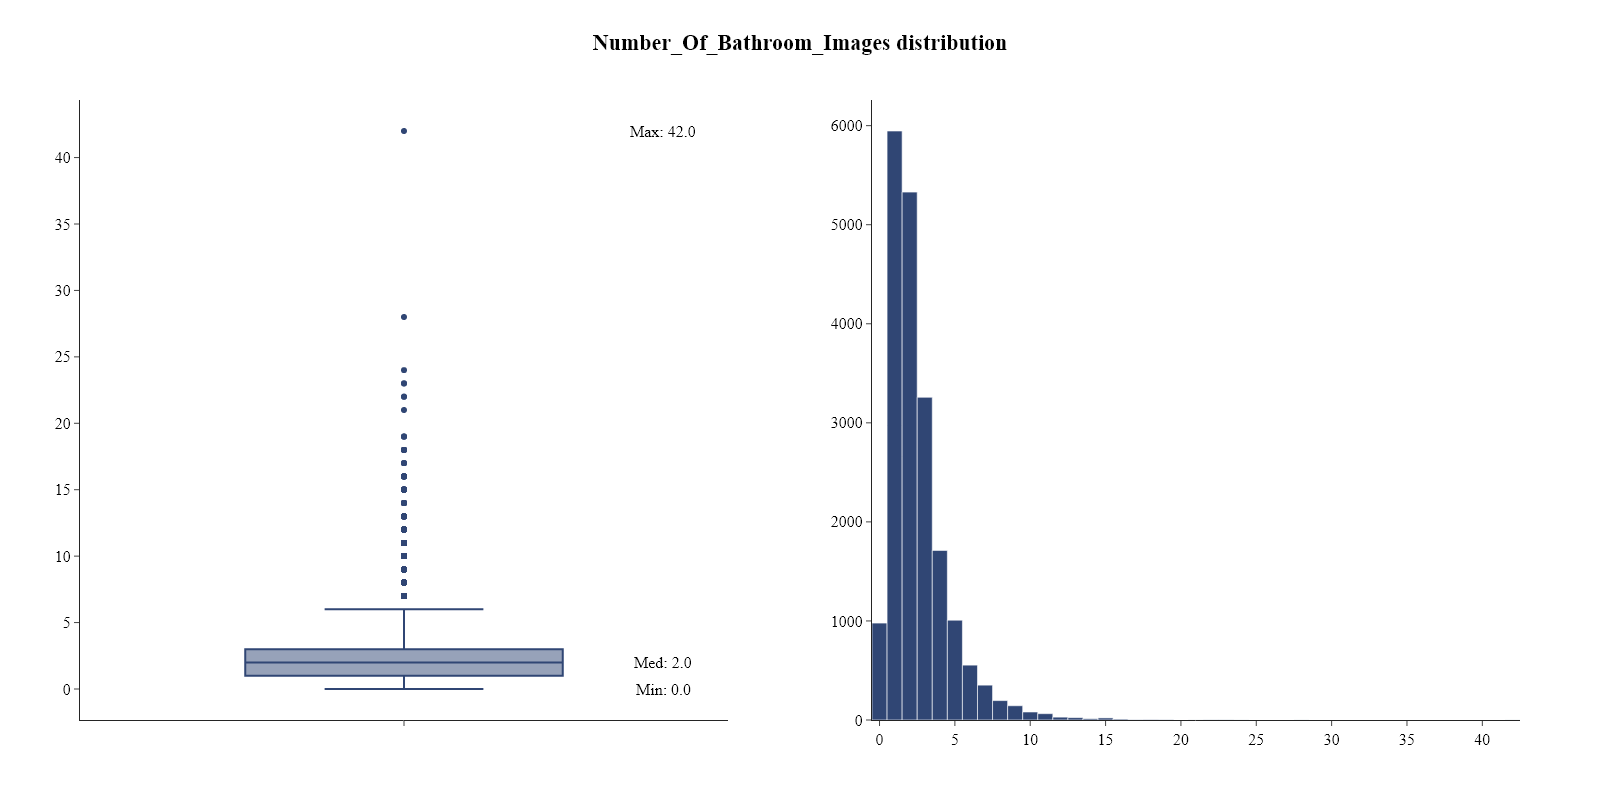

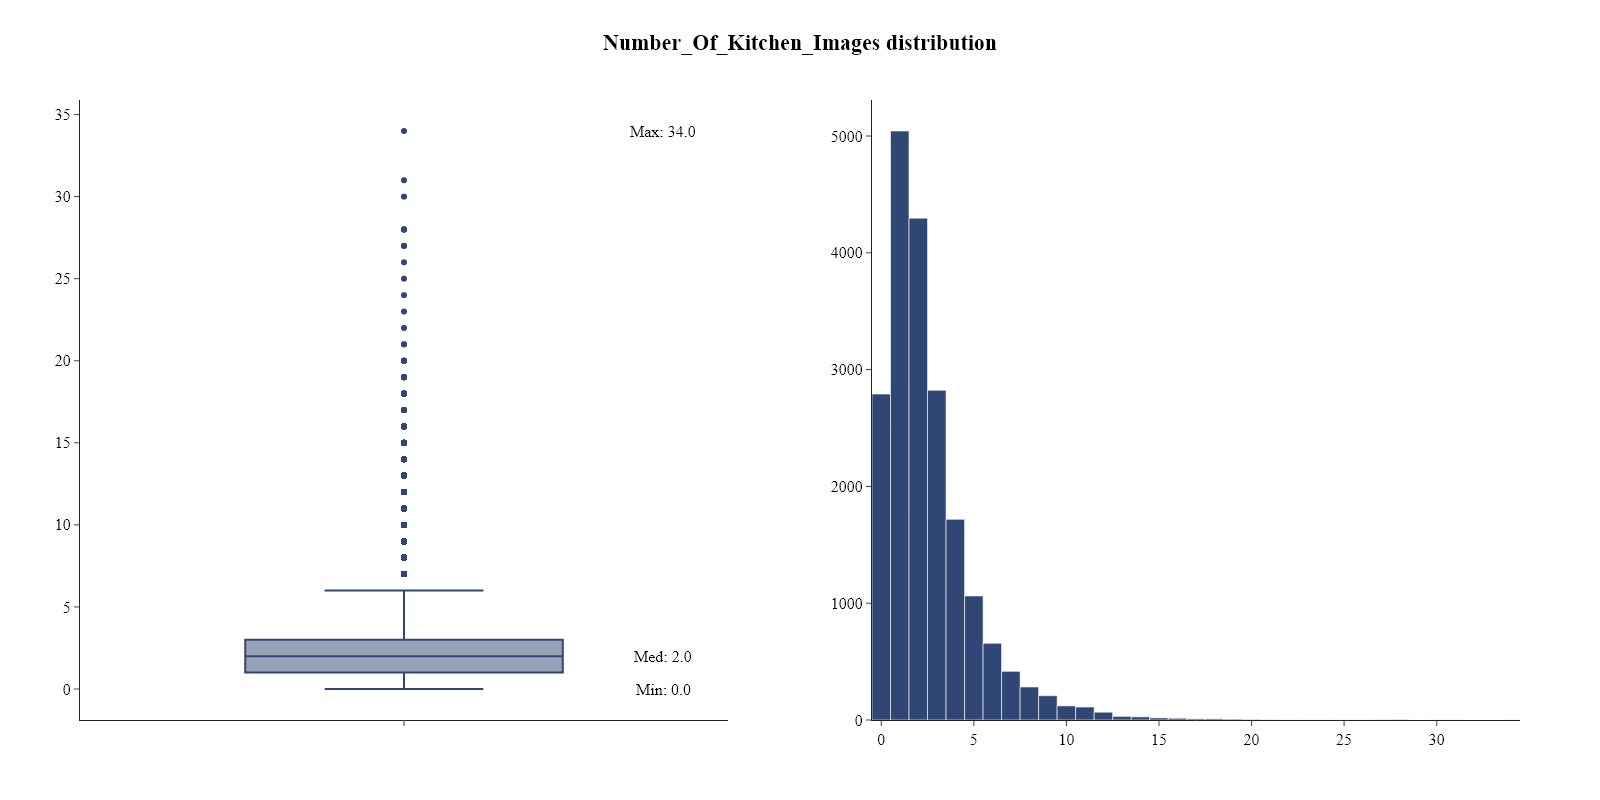

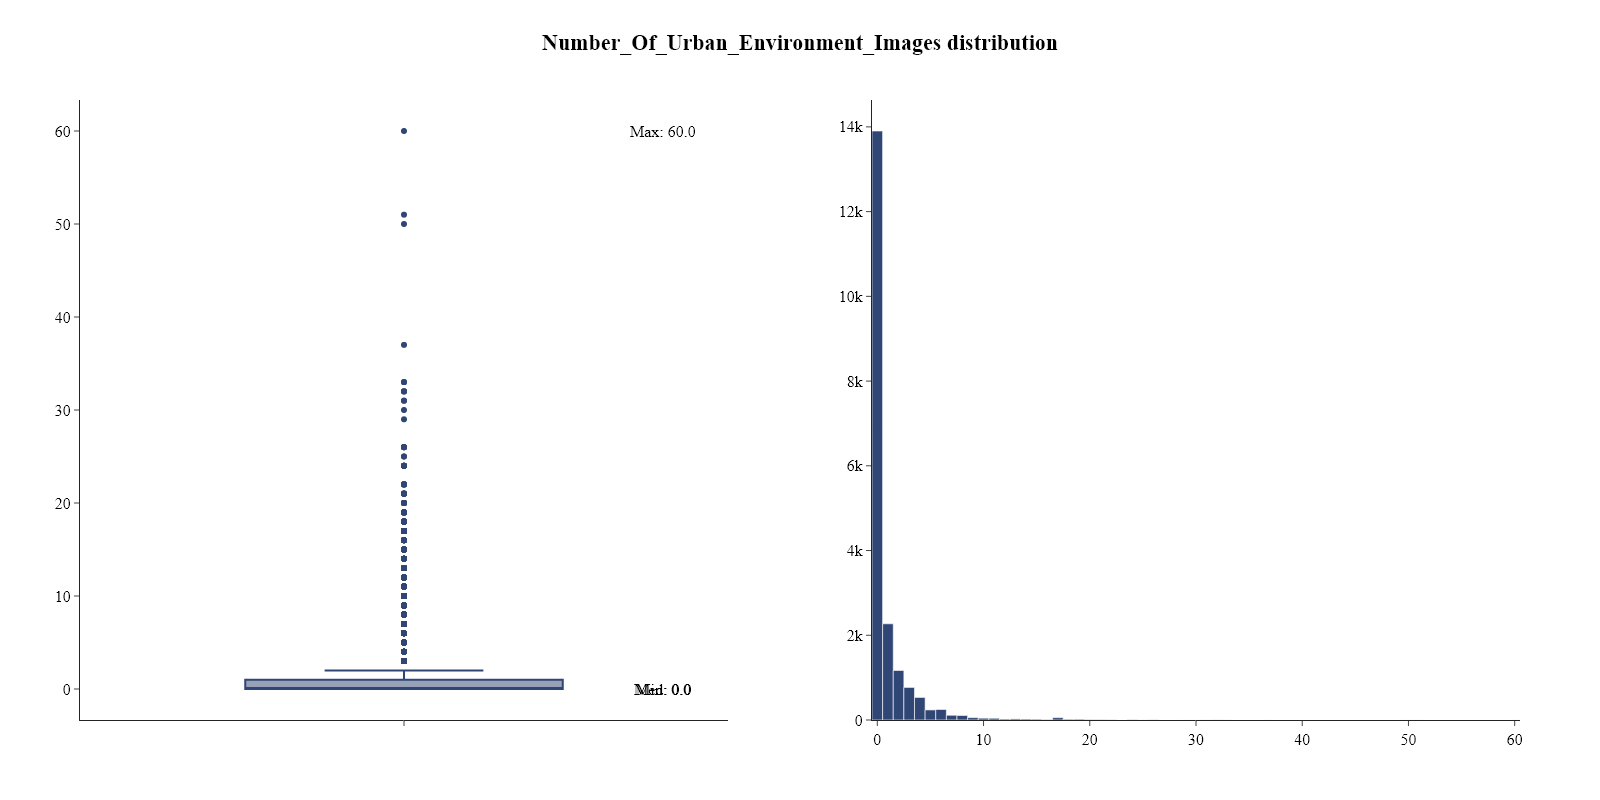

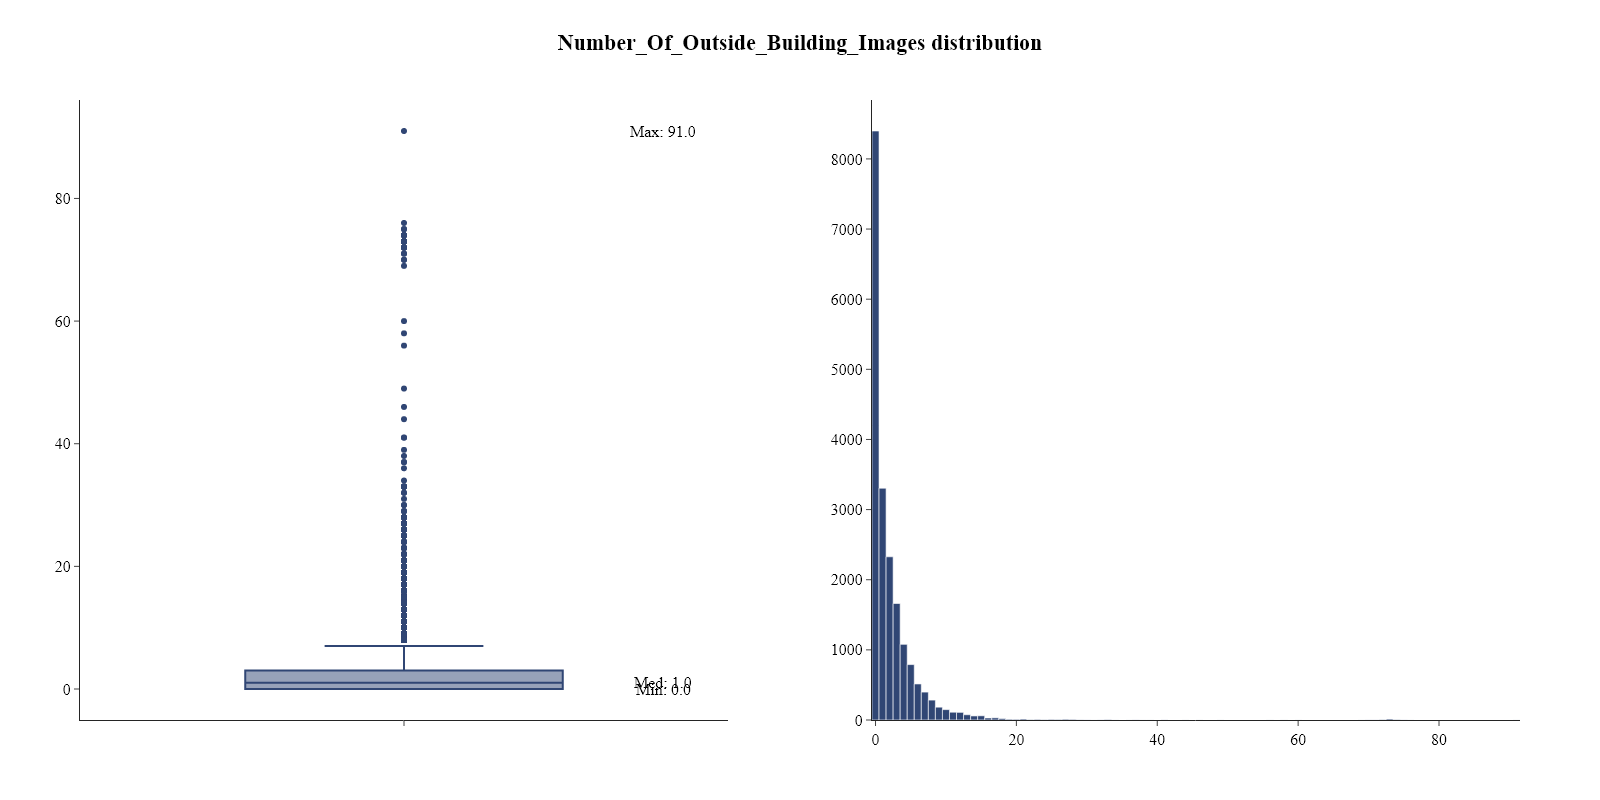

In [16]:
unique_room_types = images_data['room_type'].unique()
for room_type in unique_room_types:
    listings[f"number_of_{room_type}_images"] = listings["listing_id"].map(images_data[images_data['room_type'] == room_type]["listing_id"].value_counts())
    listings[f"number_of_{room_type}_images"].fillna(0, inplace=True) #If there are no images for a given room type, fill the missing values with 0
    plots.histogram_and_box_plot(listings[f"number_of_{room_type}_images"], name=f"number_of_{room_type}_images", annotations=["Min", "Med", "Max"], bin_size=1)

**Notes:**
- For all room type the distribution of their number in listings is right-skewed.
- The most common room type (based on the median) is Bedroom.

## Color attributes

## `warmth_hue`

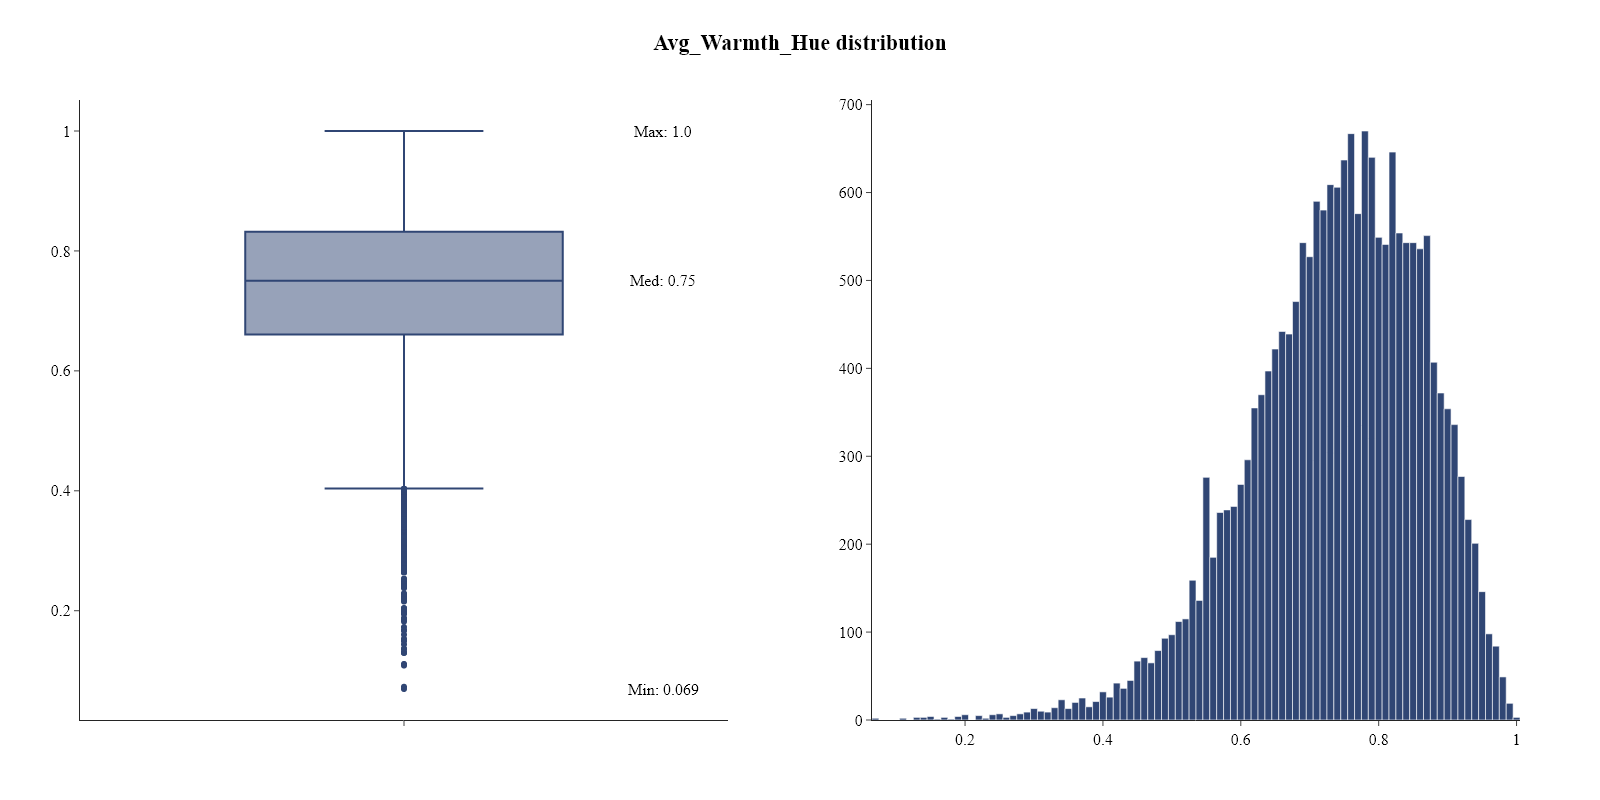

In [17]:
listings["avg_warmth_hue"] = listings["listing_id"].map(images_data.groupby("listing_id")["warmth_hue"].mean())
plots.histogram_and_box_plot(listings["avg_warmth_hue"], name="avg_warmth_hue", annotations=["Min", "Med", "Max"], bin_size=0.01)

**Notes:**
- The distribution of the warmth hue is left-skewed with median equals to 0.75

## `saturation`

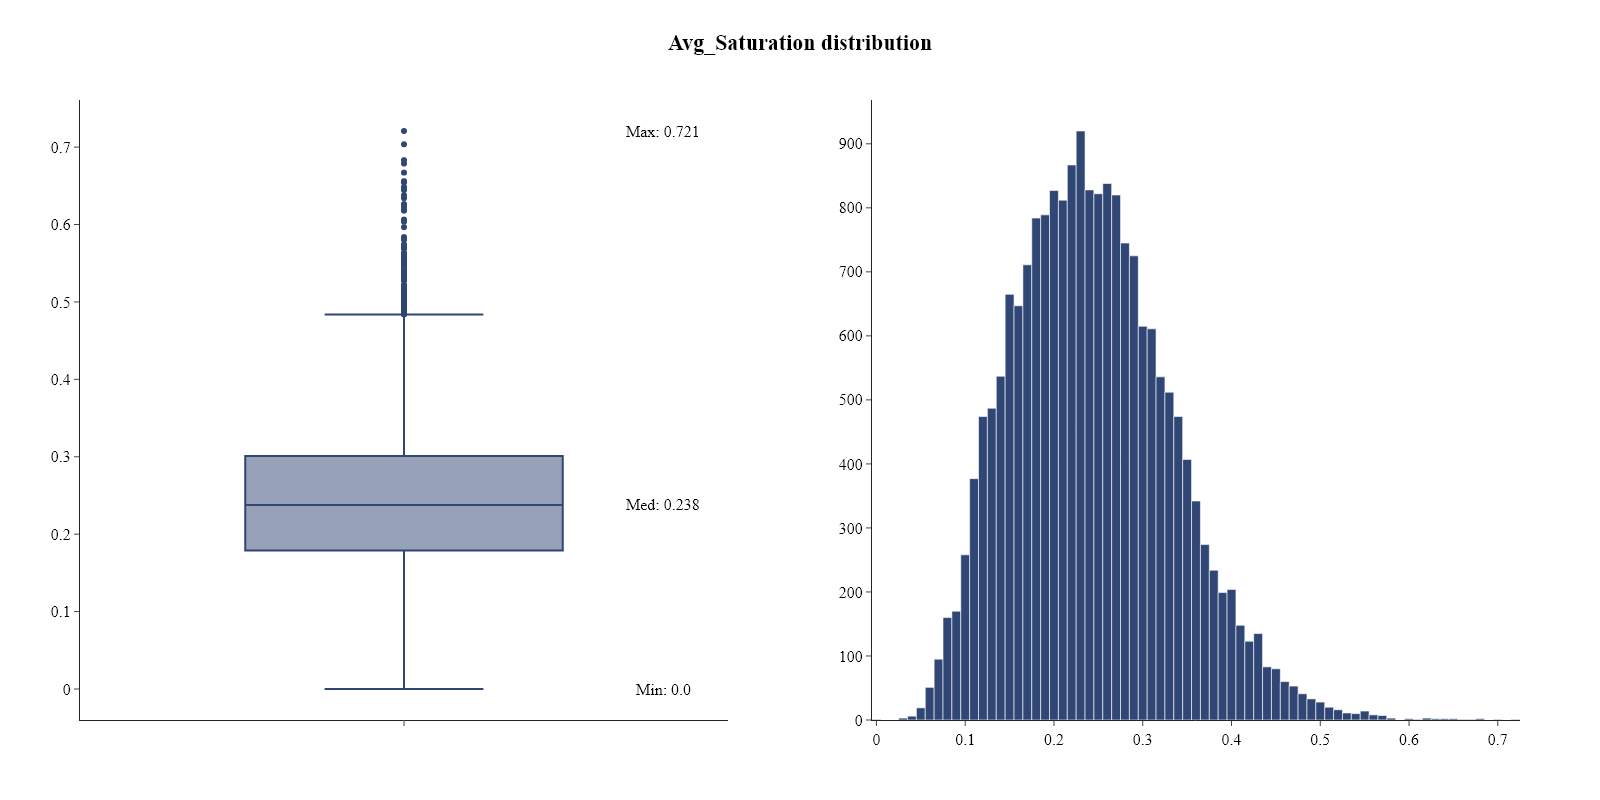

In [18]:
listings["avg_saturation"] = listings["listing_id"].map(images_data.groupby("listing_id")["saturation"].mean())
plots.histogram_and_box_plot(listings["avg_saturation"], name="avg_saturation", annotations=["Min", "Med", "Max"], bin_size=0.01)

**Notes:**
- The distribution of the saturation is a little bit right-skewed with median equals to 0.238

## `brightness`

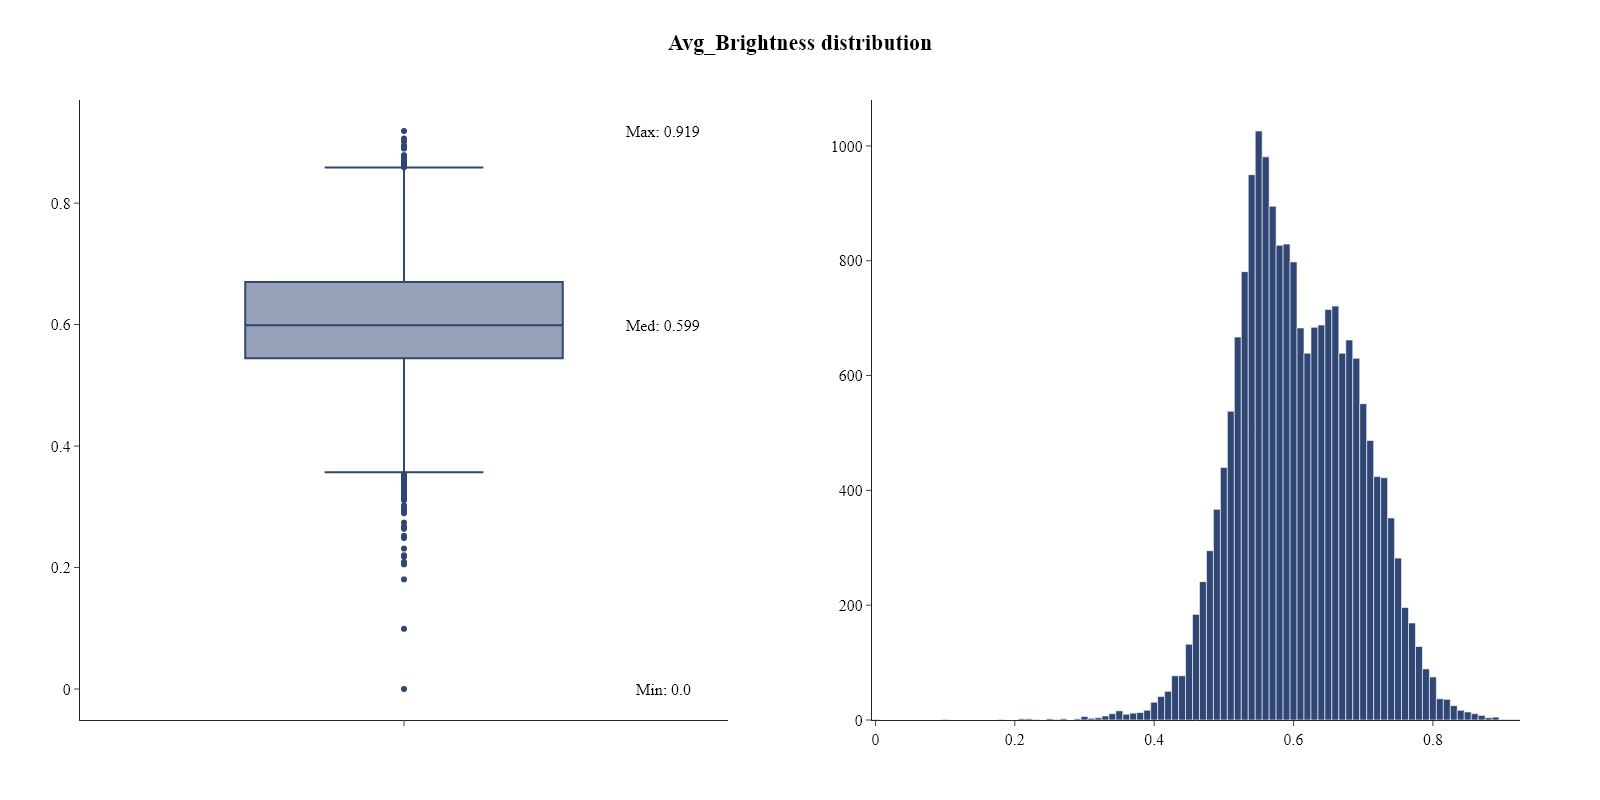

In [19]:
listings["avg_brightness"] = listings["listing_id"].map(images_data.groupby("listing_id")["brightness"].mean())
plots.histogram_and_box_plot(listings["avg_brightness"], name="avg_brightness", annotations=["Min", "Med", "Max"], bin_size=0.01)

**Notes:**
- Most of the values for `brightness` are between 0.4 and 0.8.

## `contrast_brightness`

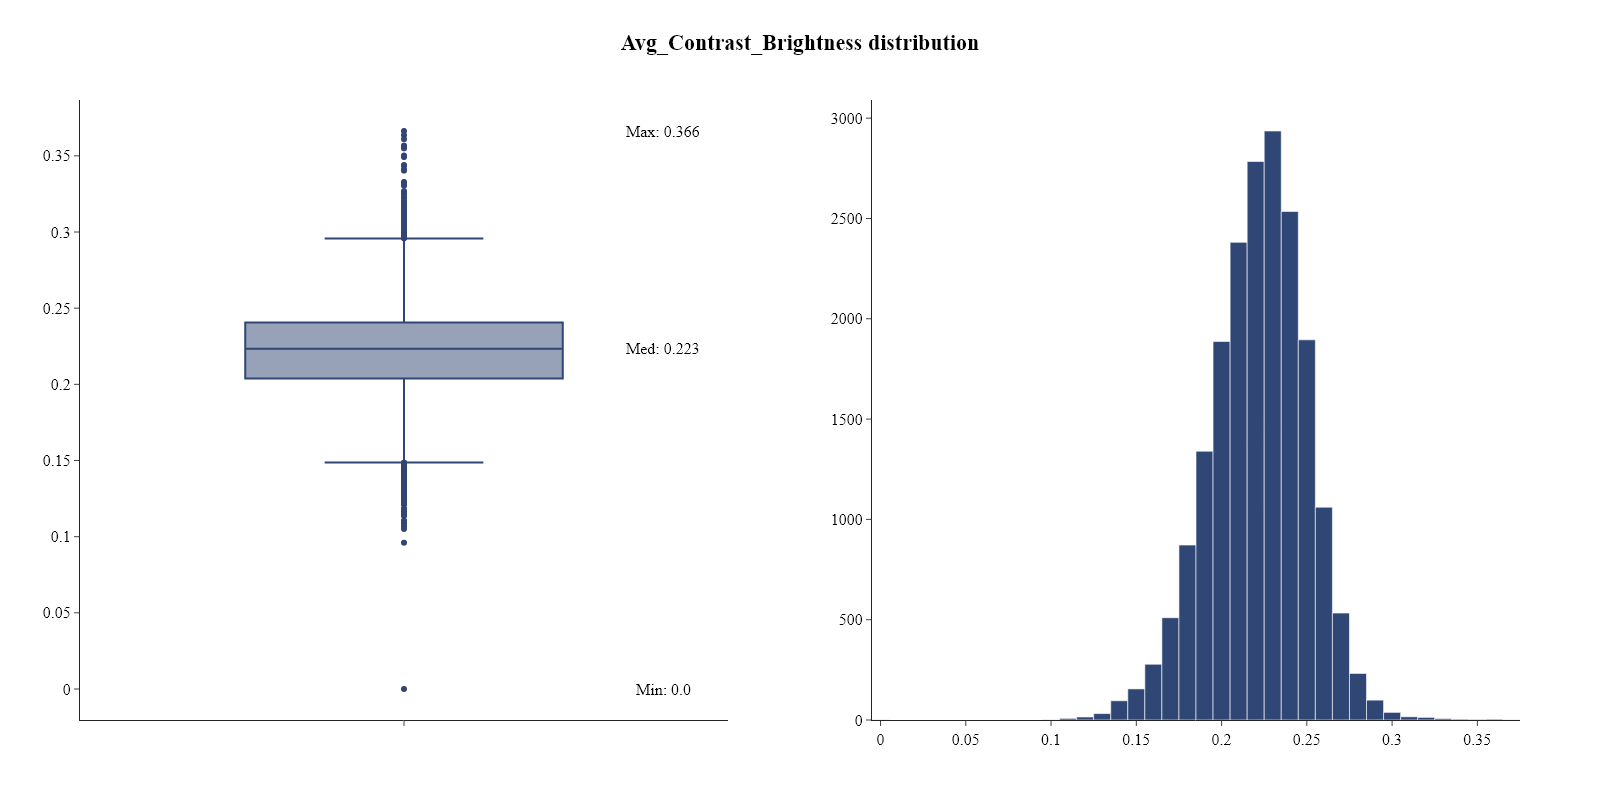

In [20]:
listings["avg_contrast_brightness"] = listings["listing_id"].map(images_data.groupby("listing_id")["contrast_brightness"].mean())
plots.histogram_and_box_plot(listings["avg_contrast_brightness"], name="avg_contrast_brightness", annotations=["Min", "Med", "Max"], bin_size=0.01)

**Notes:**
- For `contrast_brightness` there are no images which have value greater than 0.37.

## `clarity`

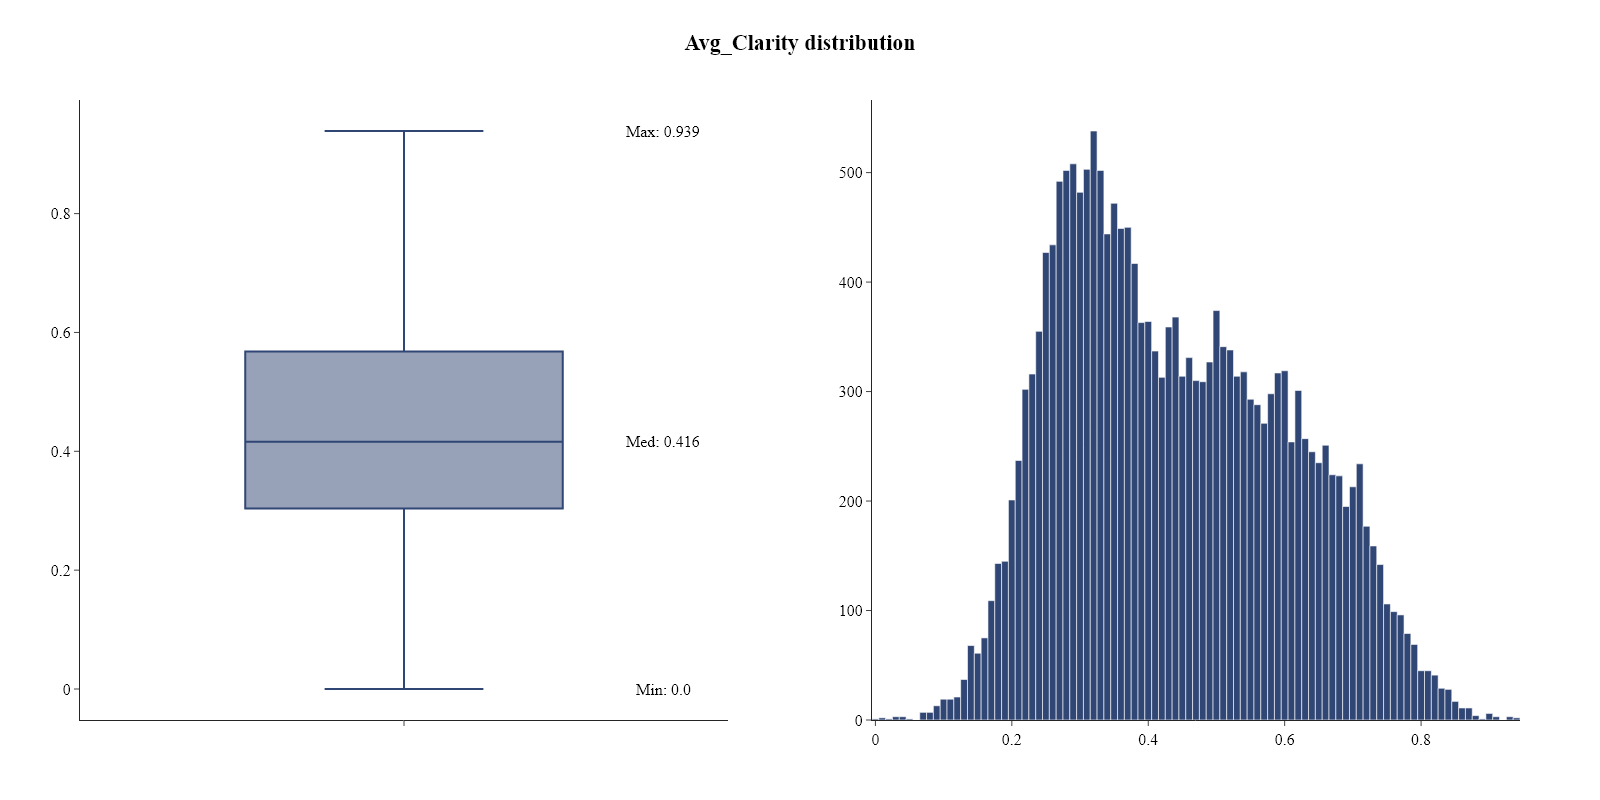

In [21]:
listings["avg_clarity"] = listings["listing_id"].map(images_data.groupby("listing_id")["clarity"].mean())
plots.histogram_and_box_plot(listings["avg_clarity"], name="avg_clarity", annotations=["Min", "Med", "Max"], bin_size=0.01)

**Notes:**
- The median of `clarity` is 0.416.

## Composition attributes

## `Rule of thirds`

In [22]:
# listings["avg_rule_of_thirds"] = listings["listing_id"].map(images_data.groupby("listing_id")["rule_of_thirds"].mean())
# plots.histogram_boxplot_linear_regression(listings, "avg_rule_of_thirds", "log_price", name="avg_rule_of_thirds", annotations=["Min", "Med", "Max"], bin_size=0.01)

## `Diagonal dominance`

In [23]:
# listings["avg_diagonal_dominance"] = listings["listing_id"].map(images_data.groupby("listing_id")["diagonal_dominance"].mean())
# plots.histogram_boxplot_linear_regression(listings, "avg_diagonal_dominance", "log_price", name="avg_diagonal_dominance", annotations=["Min", "Med", "Max"], bin_size=0.01)

## `Visual balance`

In [24]:
# listings["avg_visual_balance"] = listings["listing_id"].map(images_data.groupby("listing_id")["visual_balance"].mean())
# plots.histogram_boxplot_linear_regression(listings, "avg_visual_balance", "log_price", name="avg_visual_balance", annotations=["Min", "Med", "Max"], bin_size=0.01)

## Correlation plot

After creation of all image-based features, we will plot a correlation matrix to see how they are correlated with each other and with the target variable.

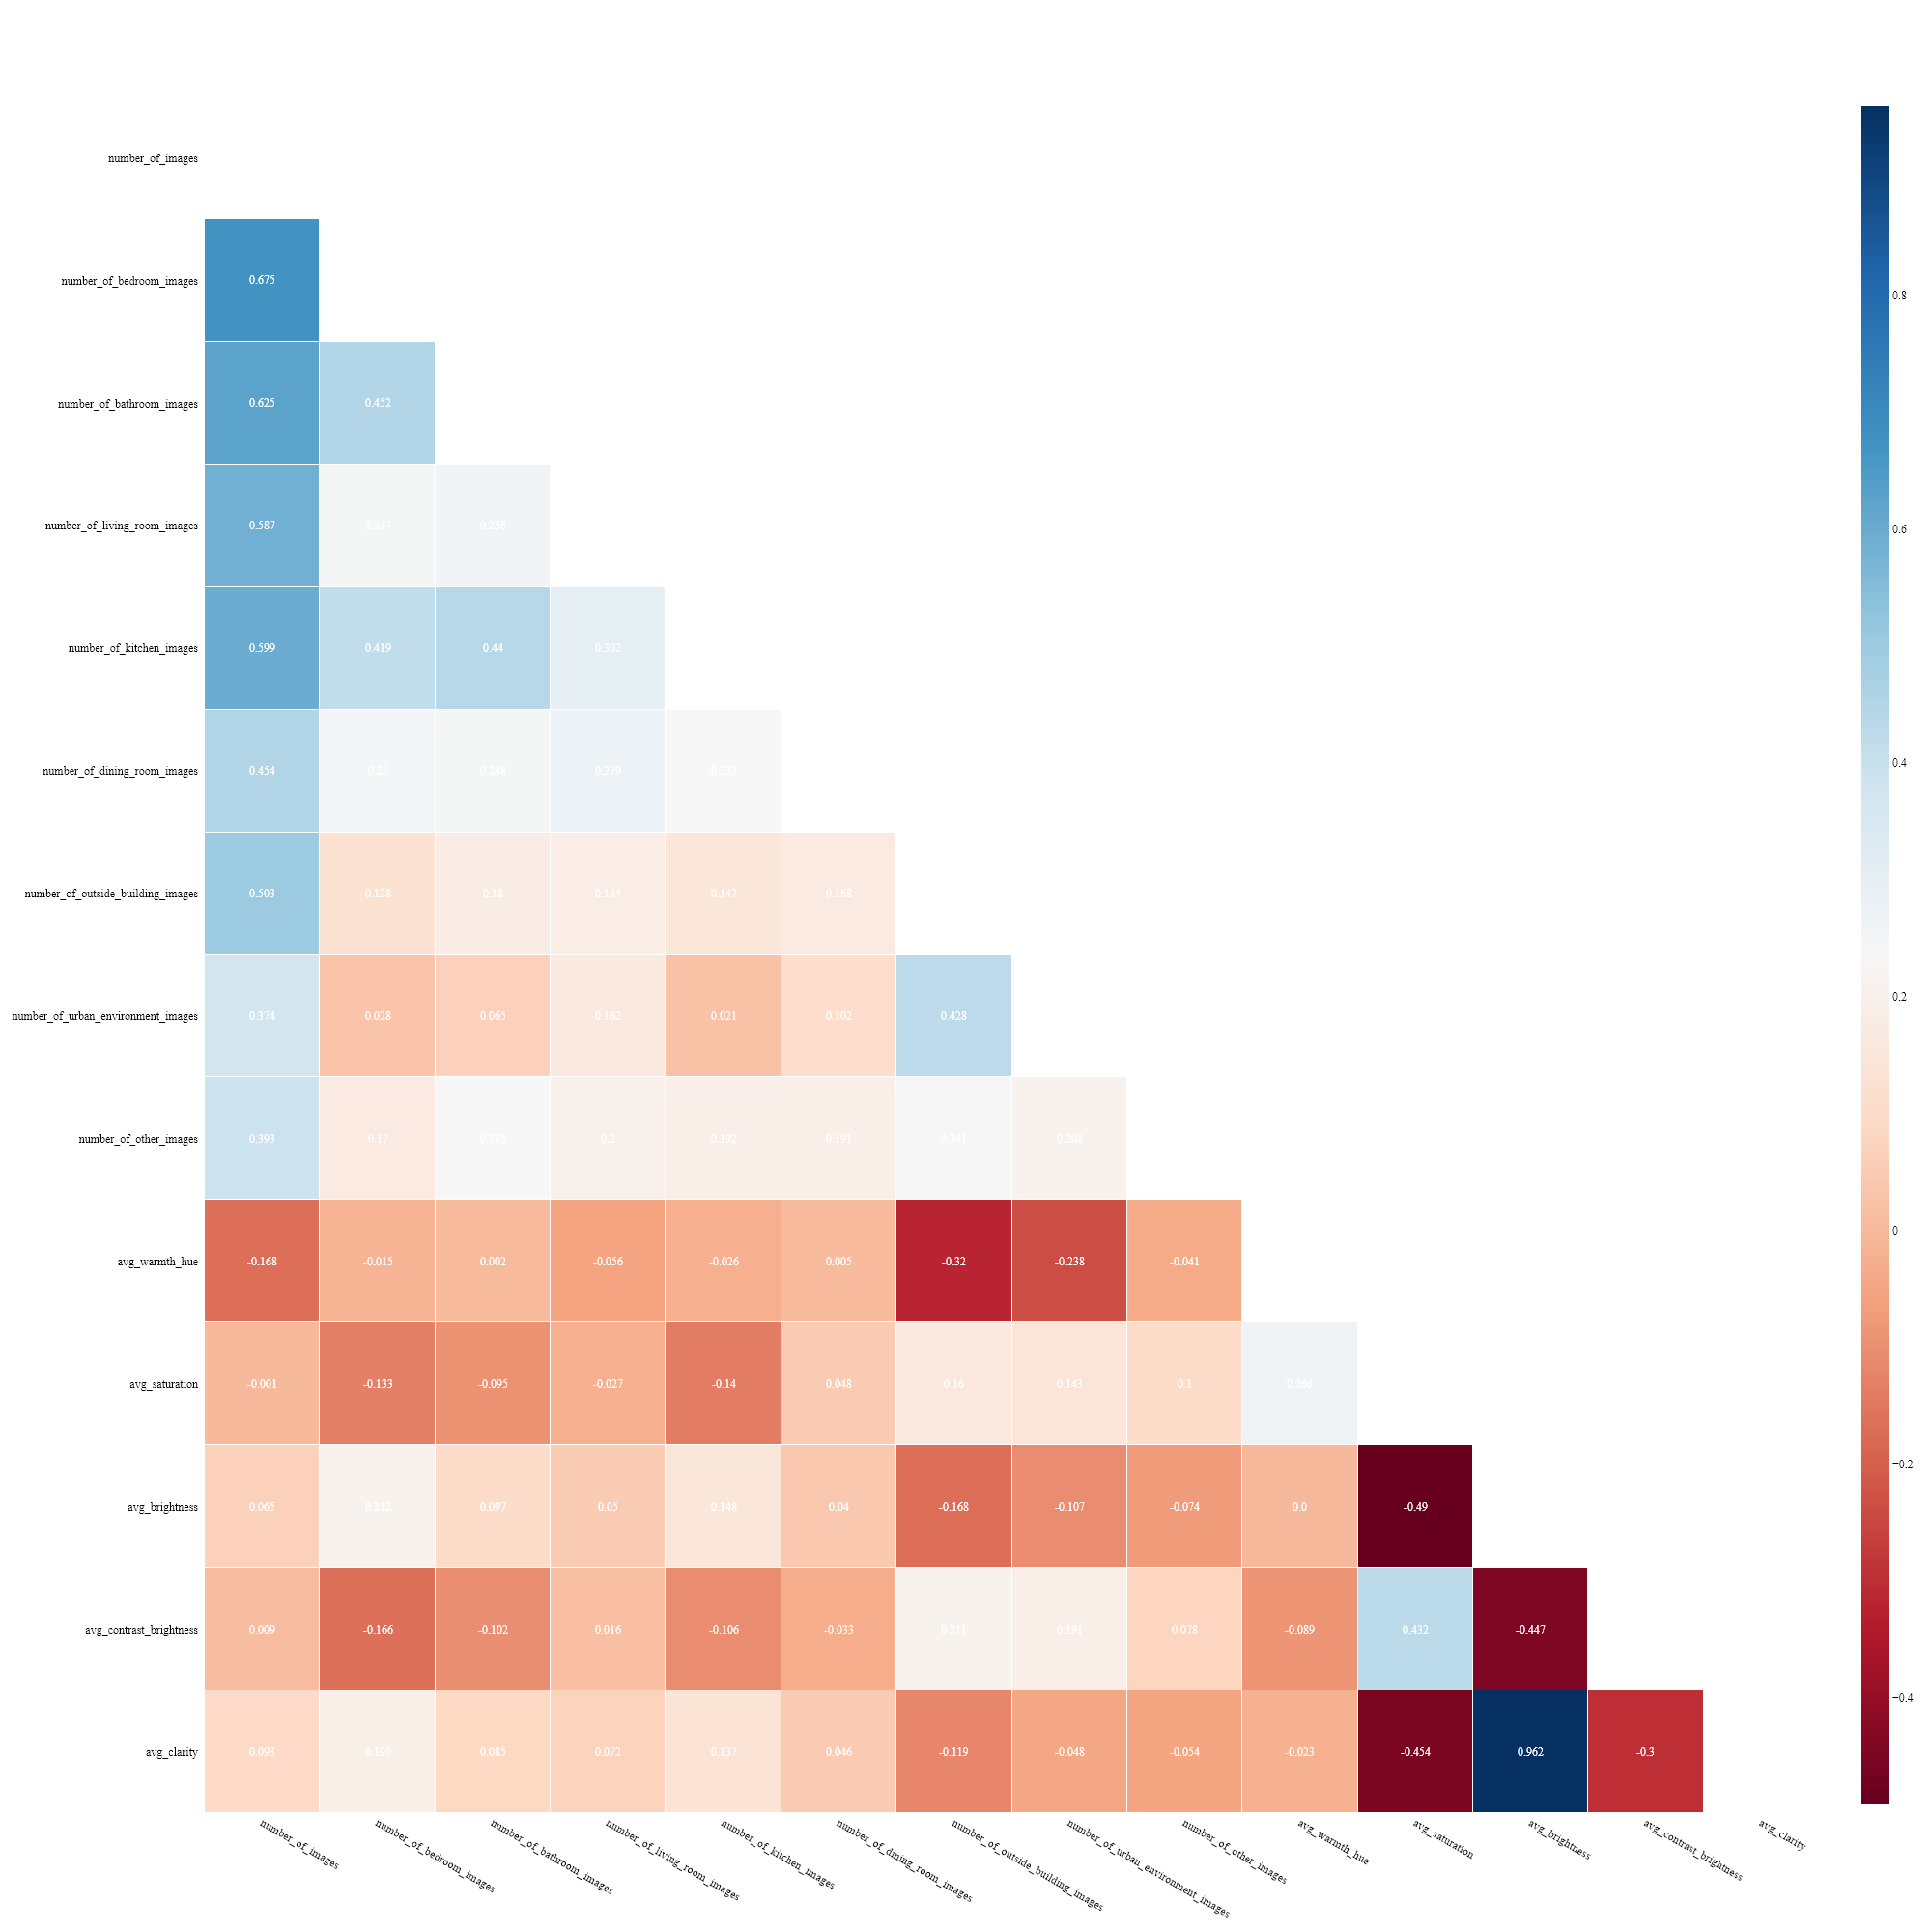

In [25]:
image_related_features = ["number_of_images", "number_of_bedroom_images", "number_of_bathroom_images", "number_of_living_room_images", "number_of_kitchen_images", "number_of_dining_room_images", "number_of_outside_building_images", "number_of_urban_environment_images", "number_of_other_images", "avg_warmth_hue", "avg_saturation", "avg_brightness", "avg_contrast_brightness", "avg_clarity"]
#"avg_rule_of_thirds", "avg_diagonal_dominance", "avg_visual_balance"
plots.correlation_plot(listings[image_related_features], method="spearman")
image_related_features.insert(0, 'listing_id')

# Save image features to DB

In [26]:
listings["number_of_bedroom_images"] = listings["number_of_bedroom_images"].astype(int)
listings["number_of_bathroom_images"] = listings["number_of_bathroom_images"].astype(int)
listings["number_of_living_room_images"] = listings["number_of_living_room_images"].astype(int)
listings["number_of_kitchen_images"] = listings["number_of_kitchen_images"].astype(int)
listings["number_of_dining_room_images"] = listings["number_of_dining_room_images"].astype(int)
listings["number_of_outside_building_images"] = listings["number_of_outside_building_images"].astype(int)
listings["number_of_urban_environment_images"] = listings["number_of_urban_environment_images"].astype(int)
listings["number_of_other_images"] = listings["number_of_other_images"].astype(int)

In [ ]:
table_name = "image_data"
drop_table_script = f"""
DROP TABLE IF EXISTS {table_name};
"""
cursor.execute(drop_table_script)

In [28]:
columns_names_and_types = dict(zip(image_related_features, listings[image_related_features].dtypes))
columns_names_and_types = {k: str(v) for k, v in columns_names_and_types.items()}
python2sql_dtype = {'int64': 'BIGINT', 'int32': 'INTEGER', 'float64': 'FLOAT', 'object': 'TEXT'}
primary_key = 'listing_id'
create_script = f"CREATE TABLE {table_name} ({', '.join([f'{k} {python2sql_dtype[v]} NOT NULL' for k, v in columns_names_and_types.items()])}, PRIMARY KEY ({primary_key}));"
cursor.execute(create_script)
DB.commit()

In [49]:
column_names = ', '.join([column for column in image_related_features])
values_string = ', '.join(['%s' for _ in range(len(image_related_features))])
insert_script = f"INSERT INTO {table_name} ({column_names}) VALUES ({values_string})"
values = listings[image_related_features].values
values = [[None if pd.isnull(value) else value.strftime('%Y-%m-%d') if (isinstance(value, pd.Timestamp)) else int(value) if (isinstance(value, int)) else str(value) for value in row] for row in values]
cursor.executemany(insert_script, values)
DB.commit()